# **Location of the 20C Surface Isotherm**
Created by L. Gruenburg
Last edited 9/10/2025

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy
import numpy as np

In [3]:
# This is the OISST url for the monthly data, note that we are subsetting within the brackets []. 
# In subsequent years you will need to alter the time brackets to reflect more updated data.
url = 'http://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc?time[0:1:527],lat[500:1:550],lon[1139:1:1180],sst[0:1:527][500:1:550][1139:1:1180]'

In [4]:
# Opening the data using opendap
SST = xr.open_dataset(url)

In [8]:
# identify which data are in the nyb polygon
NYB = gpd.read_file('/Users/lauragruenburg/Desktop/NYB_Indicators_Calculations/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')
NYB = NYB.to_crs('EPSG:4326')

In [9]:
# Extract the polygon
nyb_shape = NYB.geometry[0]

In [10]:
# seasonal averaging
SST_seas = SST.groupby(['time.year','time.season']).mean('time')

In [53]:
SST_seas

<xarray.Dataset> Size: 2MB
Dimensions:  (year: 45, season: 4, lat: 51, lon: 42)
Coordinates:
  * year     (year) int64 360B 1981 1982 1983 1984 1985 ... 2022 2023 2024 2025
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float32 204B 35.12 35.38 35.62 35.88 ... 47.12 47.38 47.62
  * lon      (lon) float32 168B 284.9 285.1 285.4 285.6 ... 294.6 294.9 295.1
Data variables:
    sst      (lat, lon, year, season) float32 2MB 15.86 nan nan ... 1.978 nan
Attributes:
    Conventions:                     CF-1.5
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    institution:                     NOAA/National Centers for Environmental ...
    source:                          NOAA/NCEI https://www.ncei.noaa.gov/data...
    References:                      https://www.psl.noaa.gov/data/gridded/da...
    dataset_title:                   NOAA Daily Optimum Interpolation Sea Sur...
    version:                         Version 2.1
    comment:                         Reynolds, et al.(2007) Daily High-Resolu...
    _NCProperties:                   version=2,netcdf=4.7.0,hdf5=1.10.5,
    DODS_EXTRA.Unlimited_Dimension:  time

<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_88935/246338742.py:42: SyntaxWarning: invalid escape sequence '\c'
  ax.text(0.05, 0.9, 'Summer (JJA) Surface 20$^\circ$C Isotherm', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize = 28, color = 'white', weight = 'bold')
/opt/anaconda3/envs/indicators_env/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/indicators_env/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


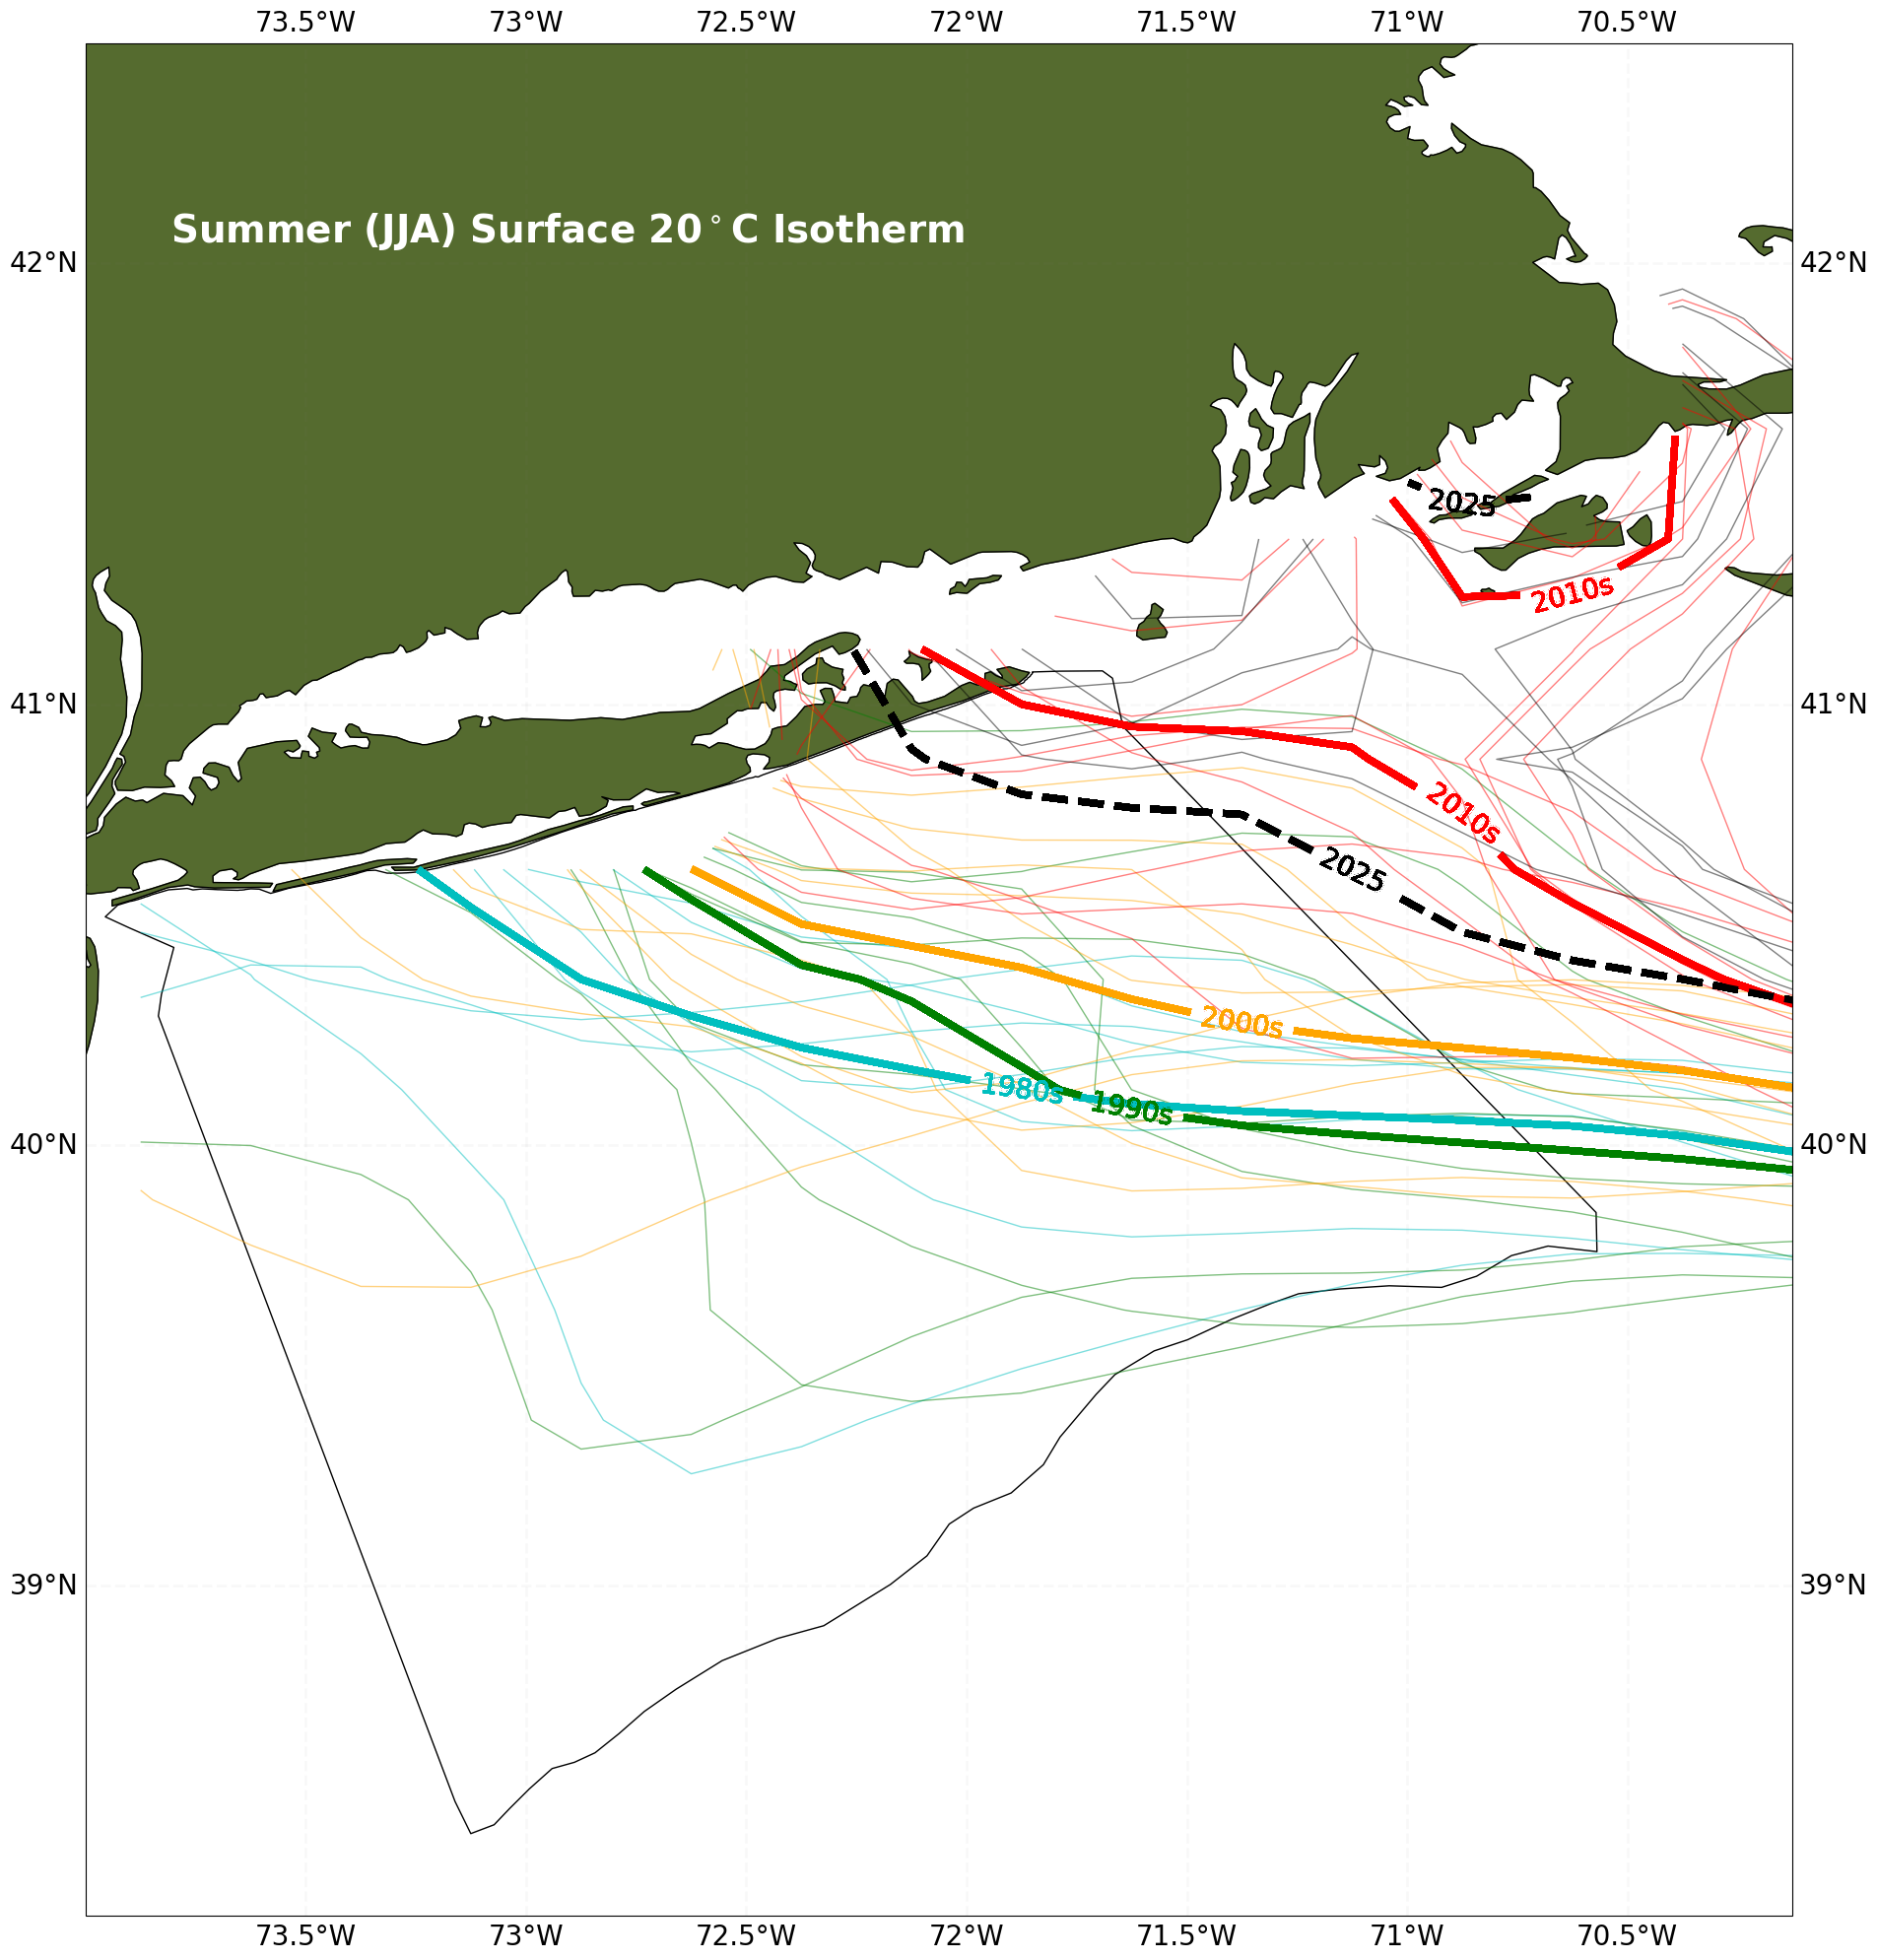

In [59]:
# June July August SST

fig,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.875,38.25,42.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
ax.coastlines(resolution='10m')
ax.set_extent(extent)
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
ax.add_geometries(NYB.geometry,
                  ccrs.PlateCarree(),
                  facecolor='none', edgecolor = 'k')
for i in range(1,45):
    if np.nanmax(SST_seas.sst[:,:,i,1]) >= 20:
        text = np.arange(1982,2026,1)
        text2 = str(text[i-1])
        if SST_seas.year[i] < 1990:
            ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,i,1], levels = [20], alpha = 0.5, linewidths = 1, colors = 'c', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon[:23],SST_seas.lat, SST_seas.sel(year = slice(1982,1989)).sst[:,:23,:,1].mean('year'),levels=[20], colors = 'c',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='1980s')

        if SST_seas.year[i] < 2000 and SST_seas.year[i] > 1989:
            ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,i,1], levels = [20], alpha = 0.5, linewidths = 1, colors = 'g', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon[:23],SST_seas.lat, SST_seas.sel(year = slice(1990,1999)).sst[:,:23,:,1].mean('year'),levels=[20], colors = 'g',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='1990s')

        if SST_seas.year[i] < 2010 and SST_seas.year[i] > 1999:
            ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,i,1], levels = [20], alpha = 0.5, linewidths = 1, colors = 'orange', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon[:23],SST_seas.lat, SST_seas.sel(year = slice(2000,2009)).sst[:,:23,:,1].mean('year'),levels=[20], colors = 'orange',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2000s')

        if SST_seas.year[i] < 2020 and SST_seas.year[i] > 2009:
            ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,i,1], levels = [20], alpha = 0.5, linewidths = 1, colors = 'r', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon[:23],SST_seas.lat, SST_seas.sel(year = slice(2010,2020)).sst[:,:23,:,1].mean('year'),levels=[20], colors = 'r',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2010s')

        if SST_seas.year[i] < 2025 and SST_seas.year[i] > 2019:
            ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,i,1], levels = [20], alpha = 0.5, linewidths = 1, colors = 'k', transform = ccrs.PlateCarree())
        
        CS1 = ax.contour(SST_seas.lon[:23], SST_seas.lat, SST_seas.sst[:,:23,44,1], levels=[20], colors = 'k',linewidths = 5, linestyles = '--')
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2025')
        
ax.text(0.05, 0.9, 'Summer (JJA) Surface 20$^\circ$C Isotherm', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize = 28, color = 'white', weight = 'bold')

gl.xlabels_top = False
gl.xlabels_bottom = True
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
gl.xlabel_style = {'size': 20, 'color': 'k'}
plt.tight_layout()

plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_88935/3854240995.py:42: SyntaxWarning: invalid escape sequence '\c'
  ax.text(0.05, 0.9, 'Autumn (SON) Surface 20$^\circ$C Isotherm', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize = 28, color = 'white', weight = 'bold')
/opt/anaconda3/envs/indicators_env/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/indicators_env/lib/python3.13/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


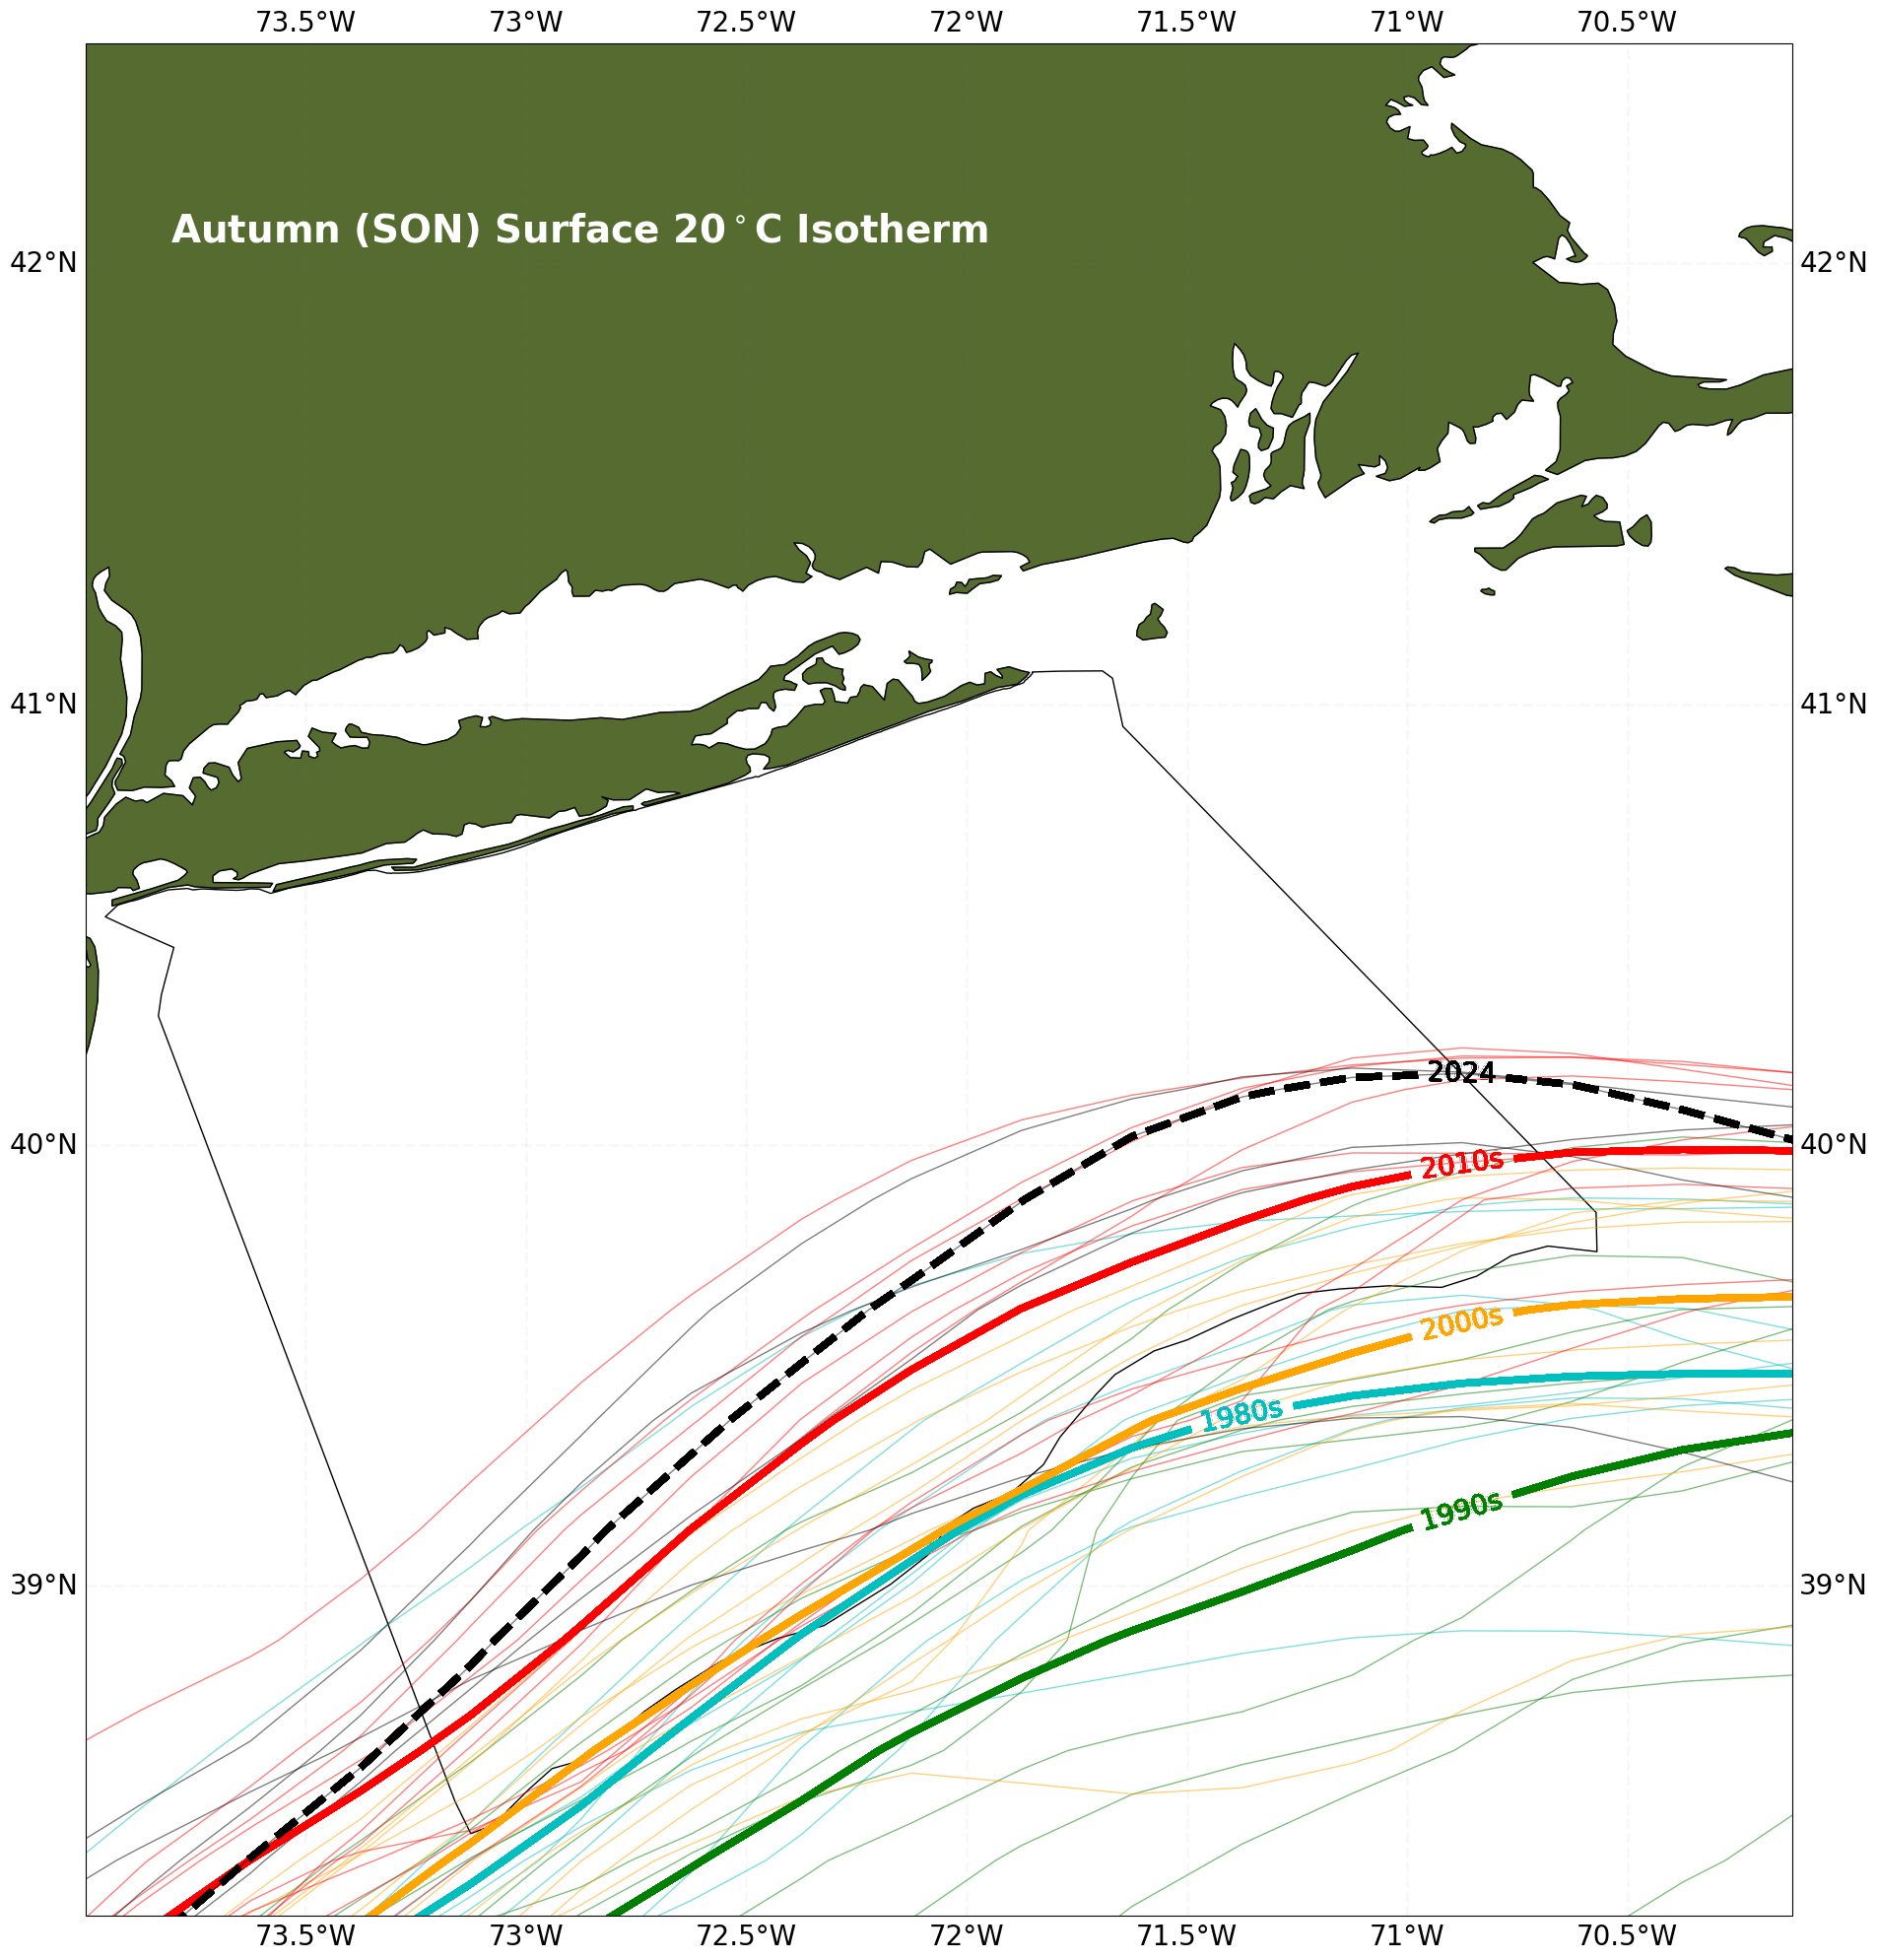

In [44]:
# September October November SST

fig,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.875,38.25,42.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.05, linestyle='--')
ax.coastlines(resolution='10m')
ax.set_extent(extent)
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
ax.add_geometries(NYB.geometry,
                  ccrs.PlateCarree(),
                  facecolor='none', edgecolor = 'k')
for i in range(1,44):
    if np.nanmax(SST_seas.sst[:,:,i,3]) >= 20:
        text = np.arange(1982,2026,1)
        text2 = str(text[i-1])
        if SST_seas.year[i] < 1990:
            ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,i,3], levels = [20], alpha = 0.5, linewidths = 1, colors = 'c', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon,SST_seas.lat, SST_seas.sel(year = slice(1982,1989)).sst[:,:,:,3].mean('year'),levels=[20], colors = 'c',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='1980s')

        if SST_seas.year[i] < 2000 and SST_seas.year[i] > 1989:
            ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,i,3], levels = [20], alpha = 0.5, linewidths = 1, colors = 'g', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon,SST_seas.lat, SST_seas.sel(year = slice(1990,1999)).sst[:,:,:,3].mean('year'),levels=[20], colors = 'g',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='1990s')

        if SST_seas.year[i] < 2010 and SST_seas.year[i] > 1999:
            ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,i,3], levels = [20], alpha = 0.5, linewidths = 1, colors = 'orange', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon,SST_seas.lat, SST_seas.sel(year = slice(2000,2009)).sst[:,:,:,3].mean('year'),levels=[20], colors = 'orange',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2000s')

        if SST_seas.year[i] < 2020 and SST_seas.year[i] > 2009:
            ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,i,3], levels = [20], alpha = 0.5, linewidths = 1, colors = 'r', transform = ccrs.PlateCarree())
        CS1 = ax.contour(SST_seas.lon,SST_seas.lat, SST_seas.sel(year = slice(2010,2020)).sst[:,:,:,3].mean('year'),levels=[20], colors = 'r',linewidths = 5)
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2010s')

        if SST_seas.year[i] < 2025 and SST_seas.year[i] > 2019:
            ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,i,3], levels = [20], alpha = 0.5, linewidths = 1, colors = 'k', transform = ccrs.PlateCarree())
        
        CS1 = ax.contour(SST_seas.lon, SST_seas.lat, SST_seas.sst[:,:,43,3], levels=[20], colors = 'k',linewidths = 5, linestyles = '--')
        ax.clabel(CS1, fontsize = 20, inline =1, fmt='2024')
        
ax.text(0.05, 0.9, 'Autumn (SON) Surface 20$^\circ$C Isotherm', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, fontsize = 28, color = 'white', weight = 'bold')

gl.xlabels_top = False
gl.xlabels_bottom = True
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
gl.xlabel_style = {'size': 20, 'color': 'k'}
plt.tight_layout()

plt.show()